# ECOSTRESS Processing Pipeline (Collection 2 / ECO_L2T_LSTE)

Steps covered in this notebook:
1. Download raw ECOSTRESS tiffs *(manual, via AppEEARS -- see note below)*
2. Parse Collection 2 tiled filenames
3. Apply QA/QC masking
4. Organize by temporal phase
5. Merge scenes <30 min apart
6. Calculate grid coverage

**Input:** a single folder containing ECOSTRESS `.tif`/`.tiff` files (any mix of `LST`, `QC`, `cloud`, `water`, `height`, `EmisWB`, `LST_err` bands). Any non-tiff files in the folder are skipped automatically.

**Output:** a new `Processed_Output` subfolder created inside the input folder, containing numbered subfolders for each processing stage, so nothing overwrites your raw downloads.


In [51]:
import os
import re
import glob
import shutil
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt


## Step 1: Download raw ECOSTRESS tiffs

This step is **manual** and happens outside this notebook, via AppEEARS (see the earlier walkthrough for submitting an Area request, uploading the ROI shapefile, and downloading the bundle).

This notebook assumes:
- All downloaded `.tif` files (across all bands and dates) are sitting in one flat folder, `INPUT_FOLDER`.
- Supporting files (README, QC lookup CSV, metadata XML, etc.) may also be in that folder -- they'll be skipped automatically since we only ever touch `.tif`/`.tiff` files.

Update the settings below to match your setup before running the rest of the notebook.


In [52]:
# ================== User Settings ==================

INPUT_FOLDER = r"/Users/ks/Desktop/Wu/Testing"   # folder full of downloaded ECOSTRESS tiffs (+ any other files, which will be skipped)

# All outputs go into a subfolder of INPUT_FOLDER so raw downloads are never modified/moved out of place
OUTPUT_ROOT = os.path.join(INPUT_FOLDER, "01_Processed_Output")
QC_MASKED_DIR   = os.path.join(OUTPUT_ROOT, "01_QC_Masked")
# PHASE_DIR       = os.path.join(OUTPUT_ROOT, "02_Organized_By_Phase")
MERGED_ROOT_DIR = os.path.join(OUTPUT_ROOT, "03_Merged")          # merged files land inside PHASE_DIR/<phase>/merged, this is just for reference
COVERAGE_DIR    = os.path.join(OUTPUT_ROOT, "02_Grid_Coverage")

for d in [OUTPUT_ROOT, QC_MASKED_DIR, COVERAGE_DIR]:
    os.makedirs(d, exist_ok=True)

# QC masking settings
# NOTE: confirm these against the ECO-L2T-LSTE-002-QC-lookup.csv that came with your
# AppEEARS download before trusting this in production -- these are placeholder "best/nominal" values.
ACCEPTABLE_QC_VALUES = [0, 1]   # QC pixel values considered good enough to keep
MASK_CLOUDS = True              # if True, also drop pixels flagged as cloud in the `cloud` band
MASK_WATER  = False             # if True, also drop pixels flagged as water in the `water` band
CLOUD_FLAG_VALUE = 0            # cloud band value meaning "clear" (anything else is masked out) -- confirm against cloud-lookup.csv
WATER_FLAG_VALUE = 0            # water band value meaning "not water" (anything else is masked out) -- confirm against docs

# Temporal organization settings
MERGE_WINDOW_MIN = 5           # merge scenes less than this many minutes apart
LOCAL_TZ = "America/Los_Angeles"
PHASE_CATEGORIES = ["Night", "Morning", "Afternoon", "Evening"]

# Grid coverage settings
GRID_SHAPEFILE = r"Grids/LA/study_region.shp"   # path to your grid shapefile
GRID_ID_FIELD = "GRID_ID"                       # unique ID field in the grid shapefile
COVERAGE_THRESHOLD = 0.50                       # >50% valid pixels required for a cell to count as "covered"


## Step 2: Parse Collection 2 tiled filenames

Collection 2 `ECO_L2T_LSTE` filenames look like:

```
ECO_L2T_LSTE.002_cloud_20180802T230140_aid0001_11N.tif
ECO_L2T_LSTE.002_LST_20180802T230140_aid0001_11N.tif
ECO_L2T_LSTE.002_QC_20180802T230140_aid0001_11N.tif
```

Each acquisition (one timestamp + tile) produces **one file per band** (`LST`, `LST_err`, `QC`, `cloud`, `water`, `height`, `EmisWB`). The functions below parse each filename and group same-acquisition band files together, so the QC/cloud files can be matched up with their corresponding LST file in the next step.

Any file that doesn't match this pattern (e.g. leftover README/CSV/metadata files, or `.tif` files that aren't ECOSTRESS output) is skipped with a printed note, rather than crashing the pipeline.


In [53]:
# Matches: ECO_L2T_LSTE.002_cloud_20180802T230140_aid0001_11N.tif
FILENAME_PATTERN = re.compile(
    r'^ECO_L2T_LSTE\.(?P<version>\d{3})_'
    r'(?P<band>LST_err|LST|QC|cloud|water|height|EmisWB)_'
    r'(?P<timestamp>\d{8}T\d{6})_'
    r'aid(?P<aid>\d+)_'
    r'(?P<utm_zone>\d{1,2}[A-Z])'
    r'\.tiff?$',
    re.IGNORECASE
)

BAND_NAMES = ["LST", "LST_err", "QC", "cloud", "water", "height", "EmisWB"]


def list_tiffs(folder_path):
    """Returns only .tif/.tiff files directly inside folder_path, skipping everything else."""
    if not os.path.isdir(folder_path):
        return []
    return [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith((".tif", ".tiff"))
    ]


def parse_ecostress_filename(path):
    """
    Parses an ECO_L2T_LSTE filename into its components.
    Returns a dict: {version, band, dt_utc, aid, utm_zone, path} or None if it doesn't match
    (e.g. a non-ECOSTRESS tiff, or a malformed name -- these are skipped, not errored on).
    """
    filename = os.path.basename(path)
    match = FILENAME_PATTERN.match(filename)
    if not match:
        print(f"  Skipping (doesn't match expected pattern): {filename}")
        return None

    try:
        dt_utc = datetime.strptime(match.group("timestamp"), "%Y%m%dT%H%M%S").replace(
            tzinfo=ZoneInfo("UTC")
        )
    except ValueError:
        print(f"  Skipping (bad timestamp): {filename}")
        return None

    return {
        "version": match.group("version"),
        "band": match.group("band"),
        "dt_utc": dt_utc,
        "aid": match.group("aid"),
        "utm_zone": match.group("utm_zone"),
        "path": path,
    }


def group_files_by_acquisition(folder_path):
    """
    Groups all band tiffs directly inside folder_path by acquisition
    (same timestamp + aid + utm_zone). Non-tiff files and non-matching
    tiffs are skipped automatically.

    Returns: {(timestamp_str, aid, utm_zone): {band_name: filepath, ...}}
    """
    groups = {}
    for fpath in list_tiffs(folder_path):
        parsed = parse_ecostress_filename(fpath)
        if parsed is None:
            continue
        key = (parsed["dt_utc"].strftime("%Y%m%dT%H%M%S"), parsed["aid"], parsed["utm_zone"])
        groups.setdefault(key, {})[parsed["band"]] = fpath
    return groups


# quick preview of what's in the input folder
print(f"Scanning {INPUT_FOLDER} ...")
acquisitions = group_files_by_acquisition(INPUT_FOLDER)
print(f"\nFound {len(acquisitions)} acquisition(s):")
for (ts, aid, utm_zone), band_files in sorted(acquisitions.items()):
    bands_present = ", ".join(sorted(band_files.keys()))
    print(f"  {ts}  (tile {utm_zone})  -> [{bands_present}]")


Scanning /Users/ks/Desktop/Wu/Testing ...

Found 13 acquisition(s):
  20180802T230140  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180802T230232  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180805T052542  (tile 11N)  -> [QC, cloud, water]
  20180805T220222  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180805T220314  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180806T211046  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180806T211138  (tile 11N)  -> [QC, cloud, water]
  20180808T042614  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180809T201128  (tile 11N)  -> [LST, LST_err, QC, cloud, height, water]
  20180809T201220  (tile 11N)  -> [QC, cloud, water]
  20180811T032656  (tile 11N)  -> [LST, LST_err, height]
  20180812T191202  (tile 11N)  -> [LST, LST_err, height]
  20180814T022729  (tile 11N)  -> [LST, LST_err, height]


## Step 3: Apply QA/QC masking

For each acquisition, this step:
1. Reads the `QC` band and keeps only pixels whose QC value is in `ACCEPTABLE_QC_VALUES`.
2. Optionally applies the `cloud` mask (drops pixels not equal to `CLOUD_FLAG_VALUE`).
3. Optionally applies the `water` mask (drops pixels not equal to `WATER_FLAG_VALUE`), if you want to exclude water surfaces.
4. Writes out a QC-masked `LST` tiff (masked pixels become `NaN`) into `01_QC_Masked/`.

Acquisitions missing an `LST` or `QC` band are skipped (printed as a warning) since masking isn't possible without both.

**Before trusting this in production:** open the `ECO-L2T-LSTE-002-QC-lookup.csv` and `ECO-L2T-LSTE-002-cloud-lookup.csv` files from your AppEEARS supporting-files download and confirm `ACCEPTABLE_QC_VALUES` / `CLOUD_FLAG_VALUE` / `WATER_FLAG_VALUE` above actually match "good quality" / "clear" / "not water" in those tables -- the defaults here are placeholders.


In [54]:
QC_LOOKUP_CSV = "ECO-L2T-LSTE-002-QC-lookup.csv"   # expected in the same directory as this notebook

# Which categories count as "acceptable" -- adjust these based on discussion with your boss.
# These reference the exact text values found in the QC lookup CSV's columns.
REQUIRE_PRODUCED_BY_TES = True   # if True, drops any QC value whose "Mandatory QA flags" says pixel was NOT produced
ACCEPTABLE_DATA_QUALITY_FLAGS = ["Good quality L1B data"]   # excludes "Missing/bad L1B data", "Missing stripe pixel..." etc.
ACCEPTABLE_LST_ACCURACY_LABELS = [
    "1 - 1.5 K (Good performance)",
    "1.5 - 2 K (Marginal performance)",
]   # excludes ">2 K (Poor performance)" by default -- add it back in if you want to keep those pixels


def load_acceptable_qc_values(qc_lookup_path, require_produced_by_tes=REQUIRE_PRODUCED_BY_TES,
                               acceptable_data_quality_flags=ACCEPTABLE_DATA_QUALITY_FLAGS,
                               acceptable_lst_accuracy_labels=ACCEPTABLE_LST_ACCURACY_LABELS):
    """
    Reads the ECO-L2T-LSTE QC lookup CSV and returns the set of integer QC pixel
    values that meet the acceptability criteria defined above.
    """
    if not os.path.isfile(qc_lookup_path):
        raise FileNotFoundError(
            f"QC lookup CSV not found: {qc_lookup_path}\n"
            f"Make sure {os.path.basename(qc_lookup_path)} is in the same directory as this notebook "
            f"(it comes with your AppEEARS supporting-files download)."
        )

    qc_lookup = pd.read_csv(qc_lookup_path)

    mask = pd.Series(True, index=qc_lookup.index)

    if require_produced_by_tes:
        mask &= qc_lookup["Mandatory QA flags"].str.startswith("Pixel produced by TES", na=False)

    mask &= qc_lookup["Data quality flag"].isin(acceptable_data_quality_flags)
    mask &= qc_lookup["LST accuracy"].isin(acceptable_lst_accuracy_labels)

    acceptable_values = set(qc_lookup.loc[mask, "Value"].astype(int))

    print(f"Loaded QC lookup: {len(qc_lookup)} total QC value(s), "
          f"{len(acceptable_values)} considered acceptable based on current criteria.")

    return acceptable_values


def apply_qc_mask(band_files, acceptable_qc_values, mask_clouds, mask_water,
                   cloud_flag_value, water_flag_value, out_path):
    """
    Reads the LST band for one acquisition, masks it using QC (+ optionally cloud/water),
    and writes the masked LST out as float32 with NaN nodata.

    acceptable_qc_values: a set/list of integer QC pixel values considered "good",
    built from load_acceptable_qc_values().

    Returns True if a masked file was written, False if skipped (missing required bands).
    """
    if "LST" not in band_files or "QC" not in band_files:
        print(f"  Skipping (missing LST or QC band)")
        return False

    with rasterio.open(band_files["LST"]) as lst_src:
        lst = lst_src.read(1).astype("float32")
        if lst_src.nodata is not None and not np.isnan(lst_src.nodata):
            lst = np.where(lst == lst_src.nodata, np.nan, lst)
        meta = lst_src.meta.copy()

    with rasterio.open(band_files["QC"]) as qc_src:
        qc = qc_src.read(1)

    good_mask = np.isin(qc, list(acceptable_qc_values))

    if mask_clouds and "cloud" in band_files:
        with rasterio.open(band_files["cloud"]) as cloud_src:
            cloud = cloud_src.read(1)
        good_mask &= (cloud == cloud_flag_value)
    elif mask_clouds:
        print(f"  Warning: MASK_CLOUDS=True but no cloud band found for this acquisition")

    if mask_water and "water" in band_files:
        with rasterio.open(band_files["water"]) as water_src:
            water = water_src.read(1)
        good_mask &= (water == water_flag_value)
    elif mask_water:
        print(f"  Warning: MASK_WATER=True but no water band found for this acquisition")

    lst_masked = np.where(good_mask, lst, np.nan)

    n_total = lst_masked.size
    n_valid = int(np.isfinite(lst_masked).sum())
    pct_valid = 100 * n_valid / n_total if n_total else 0.0

    meta.update({"dtype": "float32", "nodata": np.nan})
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(lst_masked, 1)

    print(f"  Saved -> {os.path.basename(out_path)}  ({pct_valid:.1f}% valid pixels after QC/cloud masking)")
    return True


def run_qc_masking(acquisitions, out_dir, qc_lookup_path=QC_LOOKUP_CSV):
    acceptable_qc_values = load_acceptable_qc_values(qc_lookup_path)

    print(f"\nApplying QC masking for {len(acquisitions)} acquisition(s)...")
    written = 0
    for (ts, aid, utm_zone), band_files in sorted(acquisitions.items()):
        print(f"\n{ts} (tile {utm_zone}):")
        out_name = f"ECO_L2T_LSTE_{ts}_aid{aid}_{utm_zone}_LST_qcmasked.tif"
        out_path = os.path.join(out_dir, out_name)
        if apply_qc_mask(
            band_files,
            acceptable_qc_values=acceptable_qc_values,
            mask_clouds=MASK_CLOUDS,
            mask_water=MASK_WATER,
            cloud_flag_value=CLOUD_FLAG_VALUE,
            water_flag_value=WATER_FLAG_VALUE,
            out_path=out_path,
        ):
            written += 1

    print(f"\nDone. {written} QC-masked LST file(s) written to {out_dir}")


run_qc_masking(acquisitions, QC_MASKED_DIR)

Loaded QC lookup: 209 total QC value(s), 66 considered acceptable based on current criteria.

Applying QC masking for 13 acquisition(s)...

20180802T230140 (tile 11N):
  Saved -> ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif  (40.2% valid pixels after QC/cloud masking)

20180802T230232 (tile 11N):
  Saved -> ECO_L2T_LSTE_20180802T230232_aid0001_11N_LST_qcmasked.tif  (54.4% valid pixels after QC/cloud masking)

20180805T052542 (tile 11N):
  Skipping (missing LST or QC band)

20180805T220222 (tile 11N):
  Saved -> ECO_L2T_LSTE_20180805T220222_aid0001_11N_LST_qcmasked.tif  (0.1% valid pixels after QC/cloud masking)

20180805T220314 (tile 11N):
  Saved -> ECO_L2T_LSTE_20180805T220314_aid0001_11N_LST_qcmasked.tif  (1.2% valid pixels after QC/cloud masking)

20180806T211046 (tile 11N):
  Saved -> ECO_L2T_LSTE_20180806T211046_aid0001_11N_LST_qcmasked.tif  (43.9% valid pixels after QC/cloud masking)

20180806T211138 (tile 11N):
  Skipping (missing LST or QC band)

20180808T042614 (

## Step 4: Organize by temporal phase

Each QC-masked LST file's UTC timestamp is converted to local time (`LOCAL_TZ`) and classified into a phase:

- **Night**: 12am-5am
- **Morning**: 5am-12pm
- **Afternoon**: 12pm-5pm
- **Evening**: 5pm-12am

Files are copied (not moved -- the QC-masked originals stay in `01_QC_Masked/`) into `02_Organized_By_Phase/<Phase>/`.


In [55]:
def classify_time(hour):
    """Classify an hour (0-23, local time) into a temporal phase."""
    if 0 <= hour < 5:
        return "Night"
    elif 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    else:
        return "Evening"


# filename pattern used for the QC-masked outputs from Step 3
QC_MASKED_PATTERN = re.compile(
    r'^ECO_L2T_LSTE_(?P<timestamp>\d{8}T\d{6})_aid(?P<aid>\d+)_(?P<utm_zone>\d{1,2}[A-Z])_LST_qcmasked\.tiff?$',
    re.IGNORECASE
)


def parse_qc_masked_filename(path):
    filename = os.path.basename(path)
    match = QC_MASKED_PATTERN.match(filename)
    if not match:
        print(f"  Skipping (doesn't match expected QC-masked pattern): {filename}")
        return None
    try:
        dt_utc = datetime.strptime(match.group("timestamp"), "%Y%m%dT%H%M%S").replace(tzinfo=ZoneInfo("UTC"))
    except ValueError:
        print(f"  Skipping (bad timestamp): {filename}")
        return None
    return {"dt_utc": dt_utc, "aid": match.group("aid"), "utm_zone": match.group("utm_zone"), "path": path}


def organize_by_phase(qc_masked_dir, local_tz=LOCAL_TZ):
    """
    Creates Night/Morning/Afternoon/Evening subfolders directly inside qc_masked_dir
    and MOVES each QC-masked tiff into the appropriate one based on local capture time.

    Only scans files sitting directly in qc_masked_dir (not already-organized
    subfolders), so this is safe to re-run without re-processing already-moved files.
    """
    for cat in PHASE_CATEGORIES:
        os.makedirs(os.path.join(qc_masked_dir, cat), exist_ok=True)

    classified = {cat: [] for cat in PHASE_CATEGORIES}

    for fpath in list_tiffs(qc_masked_dir):   # list_tiffs only looks at top-level files, so phase subfolders are skipped
        parsed = parse_qc_masked_filename(fpath)
        if parsed is None:
            continue

        dt_local = parsed["dt_utc"].astimezone(ZoneInfo(local_tz))
        phase = classify_time(dt_local.hour)

        dest_path = os.path.join(qc_masked_dir, phase, os.path.basename(fpath))
        shutil.move(fpath, dest_path)
        classified[phase].append((dt_local, dest_path))

    return classified


def plot_phase_counts(classified, out_dir):
    """Saves a bar plot of the number of tiffs organized into each temporal phase."""
    counts = [len(classified[phase]) for phase in PHASE_CATEGORIES]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(PHASE_CATEGORIES, counts, color=[PHASE_COLORS.get(p, "gray") for p in PHASE_CATEGORIES])

    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
                ha="center", va="bottom", fontsize=10)

    ax.set_xlabel("Temporal Phase")
    ax.set_ylabel("Number of Tiffs")
    ax.set_title("ECOSTRESS Scene Count by Temporal Phase")
    ax.grid(True, axis="y", alpha=0.3)

    out_path = os.path.join(out_dir, "phase_counts.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved -> {out_path}")
    return out_path


classified = organize_by_phase(QC_MASKED_DIR)

for phase, entries in classified.items():
    print(f"\n{phase}: {len(entries)} file(s)")
    for dt_local, path in sorted(entries):
        print(f"  {dt_local.strftime('%Y-%m-%d %H:%M:%S %Z')}  -> {os.path.basename(path)}")

plot_phase_counts(classified, QC_MASKED_DIR)


Night: 0 file(s)

Morning: 0 file(s)

Afternoon: 6 file(s)
  2018-08-02 16:01:40 PDT  -> ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif
  2018-08-02 16:02:32 PDT  -> ECO_L2T_LSTE_20180802T230232_aid0001_11N_LST_qcmasked.tif
  2018-08-05 15:02:22 PDT  -> ECO_L2T_LSTE_20180805T220222_aid0001_11N_LST_qcmasked.tif
  2018-08-05 15:03:14 PDT  -> ECO_L2T_LSTE_20180805T220314_aid0001_11N_LST_qcmasked.tif
  2018-08-06 14:10:46 PDT  -> ECO_L2T_LSTE_20180806T211046_aid0001_11N_LST_qcmasked.tif
  2018-08-09 13:11:28 PDT  -> ECO_L2T_LSTE_20180809T201128_aid0001_11N_LST_qcmasked.tif

Evening: 1 file(s)
  2018-08-07 21:26:14 PDT  -> ECO_L2T_LSTE_20180808T042614_aid0001_11N_LST_qcmasked.tif

Saved -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/01_QC_Masked/phase_counts.png


'/Users/ks/Desktop/Wu/Testing/01_Processed_Output/01_QC_Masked/phase_counts.png'

## Step 5: Merge scenes <5 min apart

Within each phase folder, consecutive scenes captured less than `MERGE_WINDOW_MIN` minutes apart are mosaicked together (mean of overlapping pixels), since they likely represent the same pass split across adjacent tiles/orbits. Merged outputs are saved to `02_Organized_By_Phase/<Phase>/merged/`.

Scenes with no close neighbor are left as single files (nothing to merge).


In [56]:
def mosaic_mean(files, out_path):
    """Mosaic a list of GeoTIFFs using the mean for overlapping pixels."""
    if len(files) == 0:
        return

    datasets = [rasterio.open(f) for f in files]
    ref = datasets[0]
    ref_crs = ref.crs

    xres, yres = ref.res
    xres, yres = abs(xres), abs(yres)

    minxs, maxxs, minys, maxys = [], [], [], []
    for ds in datasets:
        if ds.crs != ref_crs:
            raise ValueError("All rasters must have the same CRS.")
        b = ds.bounds
        minxs.append(min(b.left, b.right))
        maxxs.append(max(b.left, b.right))
        minys.append(min(b.bottom, b.top))
        maxys.append(max(b.bottom, b.top))

    minx, maxx = min(minxs), max(maxxs)
    miny, maxy = min(minys), max(maxys)

    width = int(np.ceil((maxx - minx) / xres))
    height = int(np.ceil((maxy - miny) / yres))
    mosaic_transform = from_bounds(minx, miny, maxx, maxy, width, height)

    n = len(datasets)
    stack = np.full((n, height, width), np.nan, dtype="float32")

    for i, ds in enumerate(datasets):
        data = ds.read(1).astype("float32")
        if ds.nodata is not None and not np.isnan(ds.nodata):
            data = np.where(data == ds.nodata, np.nan, data)

        dest = np.full((height, width), np.nan, dtype="float32")
        reproject(
            source=data,
            destination=dest,
            src_transform=ds.transform,
            src_crs=ds.crs,
            dst_transform=mosaic_transform,
            dst_crs=ref_crs,
            src_nodata=None,
            dst_nodata=np.nan,
            resampling=Resampling.nearest,
        )
        stack[i] = dest

    mosaic_arr = np.nanmean(stack, axis=0).astype("float32")

    meta = ref.meta.copy()
    meta.update({"height": height, "width": width, "transform": mosaic_transform,
                 "dtype": "float32", "nodata": np.nan})

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic_arr, 1)

    for ds in datasets:
        ds.close()


def group_by_time(entries, max_minutes=MERGE_WINDOW_MIN):
    """entries: list of (dt_local, path), already sorted or not."""
    max_delta = timedelta(minutes=max_minutes)
    items = sorted(entries, key=lambda x: x[0])

    groups = []
    current_group = []
    for dt_local, path in items:
        if not current_group:
            current_group = [(dt_local, path)]
            continue
        prev_dt = current_group[-1][0]
        if dt_local - prev_dt <= max_delta:
            current_group.append((dt_local, path))
        else:
            groups.append(current_group)
            current_group = [(dt_local, path)]
    if current_group:
        groups.append(current_group)
    return groups


def run_merging(qc_masked_dir, merge_window_min=MERGE_WINDOW_MIN):
    """
    Merges scenes <merge_window_min apart within each phase subfolder of
    qc_masked_dir (i.e. 01_QC_Masked/Night, .../Morning, etc.), which is where
    organize_by_phase() now moves the QC-masked tiffs.
    """
    for phase in PHASE_CATEGORIES:
        phase_folder = os.path.join(qc_masked_dir, phase)
        files = list_tiffs(phase_folder)   # only top-level files, so re-running skips the "merged" subfolder itself
        if not files:
            continue

        entries = []
        for f in files:
            parsed = parse_qc_masked_filename(f)
            if parsed is None:
                continue
            dt_local = parsed["dt_utc"].astimezone(ZoneInfo(LOCAL_TZ))
            entries.append((dt_local, f))

        groups = group_by_time(entries, max_minutes=merge_window_min)
        print(f"\n[{phase}] {len(groups)} merge group(s) from {len(entries)} file(s)")

        merged_folder = os.path.join(phase_folder, "merged")

        for i, group in enumerate(groups, start=1):
            if len(group) == 1:
                continue  # nothing to merge

            group_files = [p for _, p in group]
            dts = [dt for dt, _ in group]
            first_dt, last_dt = min(dts), max(dts)
            ts1 = first_dt.strftime("%Y%m%dT%H%M%S")
            ts2 = last_dt.strftime("%Y%m%dT%H%M%S")
            out_name = f"{phase}_group{i:03d}_{ts1}_to_{ts2}_mean.tif"
            out_path = os.path.join(merged_folder, out_name)

            print(f"  Merging {len(group_files)} file(s) -> {out_name}")
            for f in group_files:
                print(f"    {os.path.basename(f)}")

            mosaic_mean(group_files, out_path)

    print("\nMerging done.")


run_merging(QC_MASKED_DIR, merge_window_min=MERGE_WINDOW_MIN)


[Afternoon] 4 merge group(s) from 6 file(s)
  Merging 2 file(s) -> Afternoon_group001_20180802T160140_to_20180802T160232_mean.tif
    ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif
    ECO_L2T_LSTE_20180802T230232_aid0001_11N_LST_qcmasked.tif
  Merging 2 file(s) -> Afternoon_group002_20180805T150222_to_20180805T150314_mean.tif
    ECO_L2T_LSTE_20180805T220222_aid0001_11N_LST_qcmasked.tif
    ECO_L2T_LSTE_20180805T220314_aid0001_11N_LST_qcmasked.tif

[Evening] 1 merge group(s) from 1 file(s)

Merging done.


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_48926/3467192469.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_48926/3467192469.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")


## Step 6: Calculate grid coverage

For every processed tiff (both merged files and any single unmerged scenes), this computes the fraction of valid (non-NaN, QC-passed) pixels inside each grid cell of your study grid, and flags a cell as "covered" if that fraction exceeds `COVERAGE_THRESHOLD`.

Outputs to `04_Grid_Coverage/`:
- `grid_coverage_summary.csv` -- one row per tiff, with `% grid cells covered`
- one PNG per tiff showing which cells are covered (red) vs. not (white)


In [57]:
# ================== Grid Generation Settings ==================
STUDY_REGION_SHAPEFILE = r"Grids/LA/study_region.shp"   # path to the SoLA study region outline (just the boundary polygon)
GRID_CELL_SIZE_M = 1000                                    # grid cell size in meters (1000 = 1 km x 1 km)
CLIP_GRID_TO_BOUNDARY = True                                # if True, cells at the edge are clipped to the outline (partial cells); if False, full square cells are kept as long as they intersect the outline

GRID_DIR = os.path.join(COVERAGE_DIR, "01_SOLA_Grid")                       # generated grid shapefile lives in its own subfolder
GENERATED_GRID_SHP = os.path.join(GRID_DIR, "SoLA_1km_grid.shp")
SUMMARY_DIR = os.path.join(COVERAGE_DIR, "02_Summary")                    # coverage summary csv lives in its own subfolder


def build_grid_from_boundary(boundary_shp, cell_size_m=GRID_CELL_SIZE_M,
                              grid_id_field=GRID_ID_FIELD, clip_to_boundary=CLIP_GRID_TO_BOUNDARY,
                              out_grid_path=None):
    """
    Reads a study region outline shapefile and generates a regular square grid
    (cell_size_m x cell_size_m) covering it.

    Returns a GeoDataFrame with columns [grid_id_field, geometry], in the same
    CRS the grid was built in (a projected/metric CRS, auto-estimated from the
    boundary if it isn't already projected).
    """
    if not os.path.isfile(boundary_shp):
        raise FileNotFoundError(f"Study region shapefile not found: {boundary_shp}")

    boundary_gdf = gpd.read_file(boundary_shp)

    if boundary_gdf.crs is None:
        raise ValueError("Study region shapefile has no CRS defined -- fix the .prj before proceeding.")

    if boundary_gdf.crs.is_geographic:
        projected_crs = boundary_gdf.estimate_utm_crs()
        print(f"Boundary CRS is geographic ({boundary_gdf.crs}); reprojecting to {projected_crs} to build grid in meters.")
        boundary_gdf = boundary_gdf.to_crs(projected_crs)
    else:
        projected_crs = boundary_gdf.crs

    boundary_union = boundary_gdf.geometry.union_all()
    minx, miny, maxx, maxy = boundary_union.bounds

    x_coords = np.arange(minx, maxx + cell_size_m, cell_size_m)
    y_coords = np.arange(miny, maxy + cell_size_m, cell_size_m)

    cells = []
    for x in x_coords[:-1]:
        for y in y_coords[:-1]:
            cell = box(x, y, x + cell_size_m, y + cell_size_m)
            if not cell.intersects(boundary_union):
                continue
            if clip_to_boundary:
                cell = cell.intersection(boundary_union)
                if cell.is_empty:
                    continue
            cells.append(cell)

    grid_gdf = gpd.GeoDataFrame(
        {grid_id_field: range(1, len(cells) + 1)},
        geometry=cells,
        crs=projected_crs,
    )

    print(f"Generated {len(grid_gdf)} grid cell(s) ({cell_size_m}m x {cell_size_m}m) covering the study region.")

    if out_grid_path:
        os.makedirs(os.path.dirname(out_grid_path), exist_ok=True)
        grid_gdf.to_file(out_grid_path)
        print(f"Saved grid -> {out_grid_path}")

    return grid_gdf, boundary_gdf


def plot_boundary_vs_grid(boundary_gdf, grid_gdf, out_dir):
    """Saves a side-by-side PNG: study region outline vs. generated grid.
    This is the ONE file that stays directly in out_dir (COVERAGE_DIR), not in a subfolder."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    boundary_gdf.plot(ax=axes[0], color="lightblue", edgecolor="black", linewidth=1)
    axes[0].set_title("Study Region Outline (SoLA)")
    axes[0].axis("off")

    grid_gdf.plot(ax=axes[1], facecolor="none", edgecolor="black", linewidth=0.3)
    boundary_gdf.boundary.plot(ax=axes[1], color="red", linewidth=1.5)
    axes[1].set_title(f"Generated {GRID_CELL_SIZE_M}m Grid ({len(grid_gdf)} cells) over Outline")
    axes[1].axis("off")

    out_path = os.path.join(out_dir, "03_boundary_vs_grid_comparison.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved comparison plot -> {out_path}")
    return out_path


def find_all_processed_tiffs(qc_masked_dir):
    """Finds every tiff under qc_masked_dir (QC-masked phase files + merged subfolders)."""
    tiff_paths = []
    for dirpath, dirnames, filenames in os.walk(qc_masked_dir):
        for fname in filenames:
            if fname.lower().endswith((".tif", ".tiff")):
                tiff_paths.append(os.path.join(dirpath, fname))
    return sorted(tiff_paths)


def compute_grid_coverage(grid_orig, raster_path, threshold=COVERAGE_THRESHOLD):
    grid = grid_orig.reset_index(drop=True).copy()

    with rasterio.open(raster_path) as src:
        grid_work = grid.to_crs(src.crs)
        raster_extent = box(*src.bounds)

        valid_frac = np.zeros(len(grid_work), dtype="float32")

        for i, row in grid_work.iterrows():
            geom = row.geometry
            if not geom.intersects(raster_extent):
                continue
            geom_clip = geom.intersection(raster_extent)
            if geom_clip.is_empty:
                continue
            try:
                out_img, out_transform = rio_mask(src, [geom_clip], crop=True, filled=True, nodata=np.nan)
            except ValueError:
                continue

            data = out_img[0]
            inside_mask = geometry_mask(
                [geom_clip], out_shape=data.shape, transform=out_transform,
                all_touched=False, invert=True,
            )
            n_total = int(inside_mask.sum())
            if n_total == 0:
                continue
            data_inside = np.where(inside_mask, data, np.nan)
            n_valid = int(np.isfinite(data_inside).sum())
            valid_frac[i] = n_valid / n_total

    grid["valid_fraction"] = valid_frac
    grid["covered"] = grid["valid_fraction"] > threshold
    return grid


def plot_grid_coverage(grid_with_coverage, tiff_name, out_dir, threshold=COVERAGE_THRESHOLD):
    fig, ax = plt.subplots(figsize=(8, 8))
    grid_with_coverage[~grid_with_coverage["covered"]].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
    grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)
    pct_covered = 100 * grid_with_coverage["covered"].mean()
    ax.set_title(f"{tiff_name}\nGrid cells covered (>{int(threshold*100)}%): {pct_covered:.1f}%")
    ax.axis("off")
    out_path = os.path.join(out_dir, f"{tiff_name}_coverage.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path


def run_grid_coverage(qc_masked_dir, grid_gdf, grid_id_field, coverage_dir, summary_dir, threshold=COVERAGE_THRESHOLD):
    """
    Computes grid coverage for every tiff under qc_masked_dir, and saves each
    coverage PNG into coverage_dir mirroring the same Phase/merged folder
    structure the source tiff was found in (e.g. Night/, Afternoon/merged/).
    The combined summary CSV goes into summary_dir, not coverage_dir directly.
    """
    files = find_all_processed_tiffs(qc_masked_dir)
    if not files:
        print("No processed tiffs found -- did steps 3-5 run successfully?")
        return pd.DataFrame()

    print(f"Found {len(files)} tiff(s) to compute coverage for")

    summary_rows = []
    for f in files:
        rel_path = os.path.relpath(f, qc_masked_dir)   # e.g. "Night/merged/xxx.tif" or "Morning/xxx.tif"
        rel_dir = os.path.dirname(rel_path)             # e.g. "Night/merged" or "Morning" or "" (shouldn't happen post-organize)
        tiff_name = os.path.splitext(os.path.basename(f))[0]
        print(f"Processing {rel_path} ...")

        grid_cov = compute_grid_coverage(grid_gdf, f, threshold=threshold)
        n_total = len(grid_cov)
        n_covered = int(grid_cov["covered"].sum())
        pct_covered = 100 * n_covered / n_total if n_total else 0.0

        summary_rows.append({
            "tiff_file": rel_path,
            "n_grid_cells": n_total,
            "n_covered": n_covered,
            "pct_covered": pct_covered,
        })

        # mirror the Phase/merged structure from qc_masked_dir inside coverage_dir
        out_subdir = os.path.join(coverage_dir, rel_dir) if rel_dir else coverage_dir
        os.makedirs(out_subdir, exist_ok=True)
        plot_grid_coverage(grid_cov, tiff_name, out_subdir, threshold=threshold)

    summary_df = pd.DataFrame(summary_rows)
    os.makedirs(summary_dir, exist_ok=True)
    summary_csv_path = os.path.join(summary_dir, "grid_coverage_summary.csv")
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"\nSaved summary -> {summary_csv_path}")

    return summary_df


# Build the grid from the study region outline, save it, and compare visually
grid_gdf, boundary_gdf = build_grid_from_boundary(
    STUDY_REGION_SHAPEFILE,
    cell_size_m=GRID_CELL_SIZE_M,
    grid_id_field=GRID_ID_FIELD,
    clip_to_boundary=CLIP_GRID_TO_BOUNDARY,
    out_grid_path=GENERATED_GRID_SHP,
)
plot_boundary_vs_grid(boundary_gdf, grid_gdf, COVERAGE_DIR)

# Run grid coverage using the generated grid
coverage_summary = run_grid_coverage(
    QC_MASKED_DIR, grid_gdf, GRID_ID_FIELD, COVERAGE_DIR, SUMMARY_DIR, threshold=COVERAGE_THRESHOLD
)
coverage_summary

Boundary CRS is geographic (EPSG:4326); reprojecting to EPSG:32611 to build grid in meters.
Generated 3416 grid cell(s) (1000m x 1000m) covering the study region.
Saved grid -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/01_SOLA_Grid/SoLA_1km_grid.shp
Saved comparison plot -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/03_boundary_vs_grid_comparison.png
Found 9 tiff(s) to compute coverage for
Processing Afternoon/ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif ...
Processing Afternoon/ECO_L2T_LSTE_20180802T230232_aid0001_11N_LST_qcmasked.tif ...
Processing Afternoon/ECO_L2T_LSTE_20180805T220222_aid0001_11N_LST_qcmasked.tif ...


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_48926/897544997.py:143: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)


Processing Afternoon/ECO_L2T_LSTE_20180805T220314_aid0001_11N_LST_qcmasked.tif ...


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_48926/897544997.py:143: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)


Processing Afternoon/ECO_L2T_LSTE_20180806T211046_aid0001_11N_LST_qcmasked.tif ...
Processing Afternoon/ECO_L2T_LSTE_20180809T201128_aid0001_11N_LST_qcmasked.tif ...
Processing Afternoon/merged/Afternoon_group001_20180802T160140_to_20180802T160232_mean.tif ...
Processing Afternoon/merged/Afternoon_group002_20180805T150222_to_20180805T150314_mean.tif ...


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_48926/897544997.py:143: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)


Processing Evening/ECO_L2T_LSTE_20180808T042614_aid0001_11N_LST_qcmasked.tif ...

Saved summary -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/grid_coverage_summary.csv


,tiff_file,n_grid_cells,n_covered,pct_covered
0,Afternoon/ECO_L2T_LSTE_20180802T230140_aid0001...,3416,1379,40.368852
1,Afternoon/ECO_L2T_LSTE_20180802T230232_aid0001...,3416,2041,59.748244
2,Afternoon/ECO_L2T_LSTE_20180805T220222_aid0001...,3416,0,0.000000
3,Afternoon/ECO_L2T_LSTE_20180805T220314_aid0001...,3416,0,0.000000
4,Afternoon/ECO_L2T_LSTE_20180806T211046_aid0001...,3416,1726,50.526932
5,Afternoon/ECO_L2T_LSTE_20180809T201128_aid0001...,3416,2958,86.592506
6,Afternoon/merged/Afternoon_group001_20180802T1...,3416,3349,98.038642
7,Afternoon/merged/Afternoon_group002_20180805T1...,3416,0,0.000000
8,Evening/ECO_L2T_LSTE_20180808T042614_aid0001_1...,3416,3385,99.092506


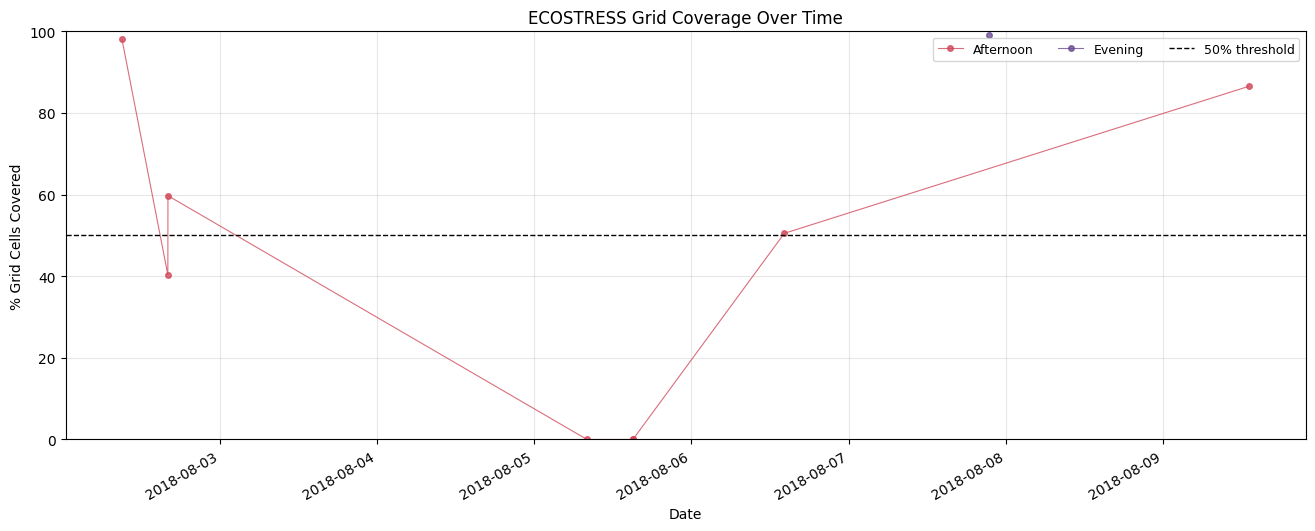

Saved -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_over_time.png

4 tiff(s) below the 50% coverage threshold:
                                                                      tiff_file                  datetime  pct_covered
            Afternoon/ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif 2018-08-02 16:01:40-07:00    40.368852
Afternoon/merged/Afternoon_group002_20180805T150222_to_20180805T150314_mean.tif 2018-08-05 08:02:22-07:00     0.000000
            Afternoon/ECO_L2T_LSTE_20180805T220222_aid0001_11N_LST_qcmasked.tif 2018-08-05 15:02:22-07:00     0.000000
            Afternoon/ECO_L2T_LSTE_20180805T220314_aid0001_11N_LST_qcmasked.tif 2018-08-05 15:03:14-07:00     0.000000


'/Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_over_time.png'

In [58]:
# ================== Coverage Over Time Plot ==================

PHASE_COLORS = {
    "Night": "#2c3e88",
    "Morning": "#e8a33d",
    "Afternoon": "#d1495b",
    "Evening": "#6a4c93",
}

# matches a YYYYMMDDTHHMMSS timestamp anywhere in the filename -- works for both
# raw QC-masked names (ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif)
# and merged names (Afternoon_group001_20180802T230140_to_20180802T231005_mean.tif),
# where it picks up the first (start) timestamp
TIMESTAMP_IN_PATH_PATTERN = re.compile(r'(\d{8}T\d{6})')


def extract_datetime_from_tiff_file(rel_path, local_tz=LOCAL_TZ):
    """
    Pulls the first timestamp out of a coverage_summary 'tiff_file' path and
    returns it as a local-time datetime, along with the phase (from the
    leading folder in the relative path, e.g. 'Night/merged/...' -> 'Night').
    Returns (None, None) if no timestamp could be parsed.
    """
    filename = os.path.basename(rel_path)
    match = TIMESTAMP_IN_PATH_PATTERN.search(filename)
    if not match:
        return None, None

    dt_utc = datetime.strptime(match.group(1), "%Y%m%dT%H%M%S").replace(tzinfo=ZoneInfo("UTC"))
    dt_local = dt_utc.astimezone(ZoneInfo(local_tz))

    phase = rel_path.split(os.sep)[0] if os.sep in rel_path else rel_path.split("/")[0]
    if phase not in PHASE_CATEGORIES:
        phase = None

    return dt_local, phase


def plot_coverage_over_time(coverage_summary_df, out_dir, threshold=COVERAGE_THRESHOLD):
    """
    Builds a line/scatter plot of % grid coverage over time (one point per
    processed tiff), colored by temporal phase, with a reference line at the
    coverage threshold. Saves to summary_dir/coverage_over_time.png.
    """
    df = coverage_summary_df.copy()

    parsed = df["tiff_file"].apply(extract_datetime_from_tiff_file)
    df["datetime"] = parsed.apply(lambda x: x[0])
    df["phase"] = parsed.apply(lambda x: x[1])

    n_unparsed = df["datetime"].isna().sum()
    if n_unparsed:
        print(f"Warning: could not parse a timestamp for {n_unparsed} row(s); excluding from plot.")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")

    if df.empty:
        print("No rows with parseable timestamps -- skipping coverage-over-time plot.")
        return None

    fig, ax = plt.subplots(figsize=(16, 6))

    for phase in PHASE_CATEGORIES:
        phase_df = df[df["phase"] == phase]
        if phase_df.empty:
            continue
        ax.plot(
            phase_df["datetime"], phase_df["pct_covered"],
            marker="o", markersize=4, linewidth=0.8, alpha=0.8,
            color=PHASE_COLORS.get(phase, "gray"), label=phase,
        )

    # catch any rows where phase couldn't be determined
    other_df = df[~df["phase"].isin(PHASE_CATEGORIES)]
    if not other_df.empty:
        ax.scatter(other_df["datetime"], other_df["pct_covered"], color="lightgray", s=15, label="Unknown phase")

    ax.axhline(threshold * 100, color="black", linestyle="--", linewidth=1, label=f"{int(threshold*100)}% threshold")

    ax.set_xlabel("Date")
    ax.set_ylabel("% Grid Cells Covered")
    ax.set_title("ECOSTRESS Grid Coverage Over Time")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper right", ncol=3, fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()

    out_path = os.path.join(out_dir, "coverage_over_time.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    # flag periods worth a closer look
    low_coverage = df[df["pct_covered"] < threshold * 100]
    if not low_coverage.empty:
        print(f"\n{len(low_coverage)} tiff(s) below the {int(threshold*100)}% coverage threshold:")
        print(low_coverage[["tiff_file", "datetime", "pct_covered"]].to_string(index=False))

    return out_path


plot_coverage_over_time(coverage_summary, SUMMARY_DIR, threshold=COVERAGE_THRESHOLD)